In [2]:
import uproot

In [3]:
    f = uproot.open('root://eospublic.cern.ch//eos/opendata/cms/datascience/HiggsToBBNtupleProducerTool/HiggsToBBNTuple_HiggsToBB_QCD_RunII_13TeV_MC/train/ntuple_merged_10.root')

In [4]:
tree = f['deepntuplizer/tree']
print(tree.num_entries)

200000


In [5]:
#shows all the columns(branches) of tree and the data type of the data stored in it
tree.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
Delta_gen_pt         | float                    | AsDtype('>f4')
event_no             | uint32_t                 | AsDtype('>u4')
gen_pt               | float                    | AsDtype('>f4')
isB                  | int32_t                  | AsDtype('>i4')
isBB                 | int32_t                  | AsDtype('>i4')
isC                  | int32_t                  | AsDtype('>i4')
isG                  | int32_t                  | AsDtype('>i4')
isLeptonicB          | int32_t                  | AsDtype('>i4')
isLeptonicB_C        | int32_t                  | AsDtype('>i4')
isS                  | int32_t                  | AsDtype('>i4')
isUD                 | int32_t                  | AsDtype('>i4')
isUndefined          | int32_t                  | AsDtype('>i4')
jet_corr_pt          | float                    | AsDtype(

In [6]:
# Returns a dictionary
labels = tree.arrays(['label_QCD_b',
                      'label_QCD_bb', 
                      'label_QCD_c', 
                      'label_QCD_cc', 
                      'label_QCD_others', 
                      'label_H_bb',
                      'sample_isQCD'], 
                     entry_stop=20000,
                     library='np')
labels

{'label_QCD_b': array([0, 0, 0, ..., 0, 0, 0], shape=(20000,), dtype=int32),
 'label_QCD_bb': array([0, 0, 0, ..., 0, 0, 0], shape=(20000,), dtype=int32),
 'label_QCD_c': array([0, 0, 0, ..., 0, 0, 0], shape=(20000,), dtype=int32),
 'label_QCD_cc': array([0, 0, 0, ..., 0, 1, 1], shape=(20000,), dtype=int32),
 'label_QCD_others': array([1, 1, 1, ..., 1, 0, 0], shape=(20000,), dtype=int32),
 'label_H_bb': array([0, 0, 0, ..., 0, 0, 0], shape=(20000,), dtype=int32),
 'sample_isQCD': array([1, 1, 1, ..., 1, 1, 1], shape=(20000,), dtype=int32)}

In [7]:
# label QCD: require the sample to be QCD and any of the QCD flavors
label_QCD = labels['sample_isQCD'] * (labels['label_QCD_b'] + \
                                      labels['label_QCD_bb'] + \
                                      labels['label_QCD_c'] + \
                                      labels['label_QCD_cc'] + \
                                      labels['label_QCD_others'])

# label Hbb
label_Hbb = labels['label_H_bb']

In [8]:
# number of overlap jets
sum(label_QCD*label_Hbb) 

np.int32(0)

In [9]:
# fraction of jets with some truth label defined 
sum(label_QCD+label_Hbb)/len(label_QCD+label_Hbb)

np.float64(0.93785)

In [11]:
# jet features, namely transverse momemntum (pt) and soft-drop mass  (sdmass or msd)
jet_features = tree.arrays(['fj_pt', 
                            'fj_sdmass'],
                          entry_stop=20000,
                          library='np')

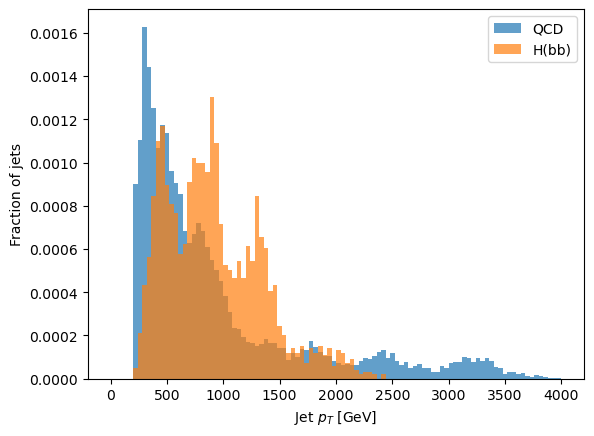

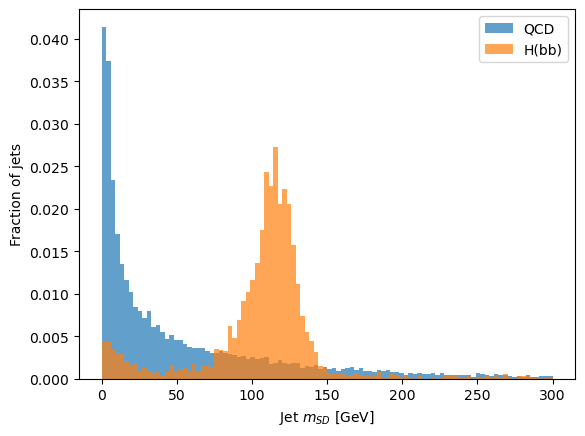

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

plt.hist(jet_features['fj_pt'],weights=label_QCD,bins=np.linspace(0,4000,101),density=True,alpha=0.7,label='QCD')
plt.hist(jet_features['fj_pt'],weights=label_Hbb,bins=np.linspace(0,4000,101),density=True,alpha=0.7,label='H(bb)')
plt.xlabel(r'Jet $p_{T}$ [GeV]')
plt.ylabel('Fraction of jets')
plt.legend()

plt.figure()

plt.hist(jet_features['fj_sdmass'],weights=label_QCD,bins=np.linspace(0,300,101),density=True,alpha=0.7,label='QCD')
plt.hist(jet_features['fj_sdmass'],weights=label_Hbb,bins=np.linspace(0,300,101),density=True,alpha=0.7,label='H(bb)')
plt.xlabel(r'Jet $m_{SD}$ [GeV]')
plt.ylabel('Fraction of jets')
plt.legend()

plt.show()

## Observation

The transverse momentum ($p_T$) distributions of Higgs and QCD jets show significant overlap, although Higgs jets tend to populate the intermediate-$p_T$ region more strongly. Therefore, jet $p_T$ alone is not sufficient for a clean separation between signal and background.

In contrast, the soft-drop mass ($m_{SD}$) distributions exhibit a clear difference. Higgs jets show a distinct peak around 125 GeV, while QCD jets are concentrated at lower masses and do not display a resonant structure. This indicates that the soft-drop mass contains valuable information for distinguishing Higgs jets from QCD jets.

## Physical Interpretation

The peak near 125 GeV arises because Higgs jets originate from the decay $H \rightarrow b\bar{b}$ and therefore retain information about the Higgs boson mass. QCD jets, on the other hand, are produced through strong-interaction processes and do not originate from a particle with a fixed mass, leading to a broader mass distribution.

The soft-drop grooming algorithm removes soft and wide-angle radiation, making the Higgs mass peak more prominent and improving its usefulness as a discriminating feature.

## Conclusion

Among the variables studied so far, the soft-drop jet mass appears to be a powerful feature for separating Higgs jets from QCD background jets and is expected to play an important role in subsequent machine-learning classifiers.

In [16]:
import awkward as ak
track_features = tree.arrays(['track_pt',
                              'label_H_bb'],
                             entry_stop=20000,
                             library='ak')
track_features

<Array [{track_pt: [...], ...}, ..., {...}] type='20000 * {track_pt: var * ...'>

In [17]:
jet_features['fj_pt'][0]

np.float32(251.27692)

In [18]:
track_features['track_pt'][0]

<Array [1.05, 0.957, 1.46, 1.09, ..., 18.2, 1.62, 1.23] type='21 * float32'>

In [20]:
print(np.sum(track_features['track_pt'][0]))

160.96143


In [21]:
ak.num(track_features['track_pt'])

<Array [21, 35, 24, 32, 28, 24, ..., 19, 16, 25, 20, 45] type='20000 * int64'>

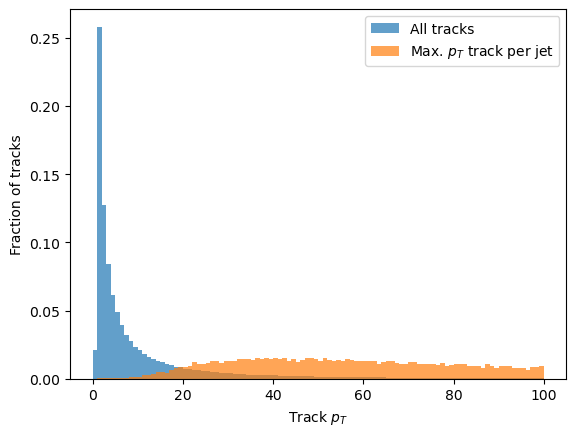

In [22]:
plt.figure()
plt.hist(ak.flatten(track_features['track_pt']),bins=np.linspace(0,100,101),density=True,alpha=0.7,label='All tracks')
plt.hist(ak.max(track_features['track_pt'], axis=-1),bins=np.linspace(0,100,101),density=True,alpha=0.7,label=r'Max. $p_{T}$ track per jet')

plt.xlabel(r'Track $p_{T}$')
plt.ylabel('Fraction of tracks')
plt.legend()
plt.show()

## Observation

The distribution of all track transverse momenta is strongly peaked at low values, with most tracks having pT below approximately 10 GeV. The distribution decreases rapidly as pT increases, indicating that low-momentum tracks dominate the jet constituents.

In contrast, the maximum track pT per jet is shifted toward much higher values. Most jets contain at least one relatively energetic track, with the maximum track pT extending up to nearly 100 GeV.

## Physical Interpretation

Jets are produced through parton showering and hadronization, which generate a large number of soft particles and a smaller number of hard particles. Consequently, most tracks inside a jet carry only a small fraction of the jet momentum, leading to the strong peak at low track pT.

The highest-pT track in a jet often originates from a leading hadron that carries a significant fraction of the parent parton's momentum. Therefore, while individual tracks are typically soft, almost every jet contains one or a few comparatively energetic tracks.

## Conclusion

The track-level pT distribution reveals the hierarchical structure of jets: many soft constituents accompanied by a few hard constituents. Features based on leading-track momentum, track multiplicity, or the momentum fraction carried by the highest-pT track may therefore provide useful information for jet classification tasks.

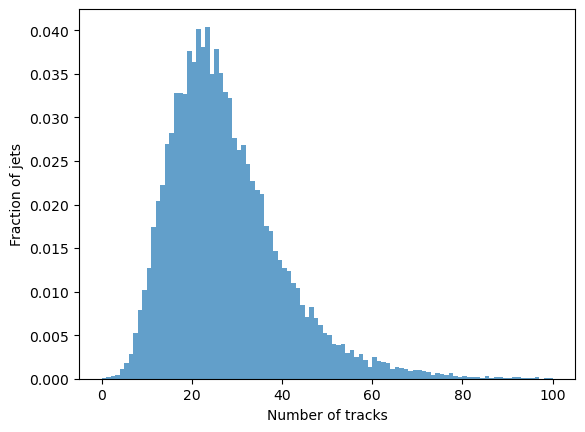

In [23]:
plt.figure()
plt.hist(ak.num(track_features['track_pt']),bins=np.linspace(0,100,101),density=True,alpha=0.7)

plt.xlabel(r'Number of tracks')
plt.ylabel('Fraction of jets')
plt.show()

In this case, 60 seems to be a reasonable number to cut

In [24]:
max_tracks = 60
pad_value = 0
a = ak.fill_none(ak.pad_none(track_features['track_pt'], max_tracks, clip=True, axis=-1), pad_value, axis=-1).to_numpy()
print(a.shape)
a

(20000, 60)


array([[ 1.05371094,  0.95654297,  1.45703125, ...,  0.        ,
         0.        ,  0.        ],
       [ 2.78320312,  3.52539062, 49.09375   , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.53027344,  6.81640625,  2.92578125, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.08105469,  2.5234375 , 10.265625  , ...,  0.        ,
         0.        ,  0.        ],
       [ 4.8125    ,  2.6796875 ,  3.98242188, ...,  0.        ,
         0.        ,  0.        ],
       [ 2.41015625,  1.43457031,  2.46289062, ...,  0.        ,
         0.        ,  0.        ]], shape=(20000, 60))

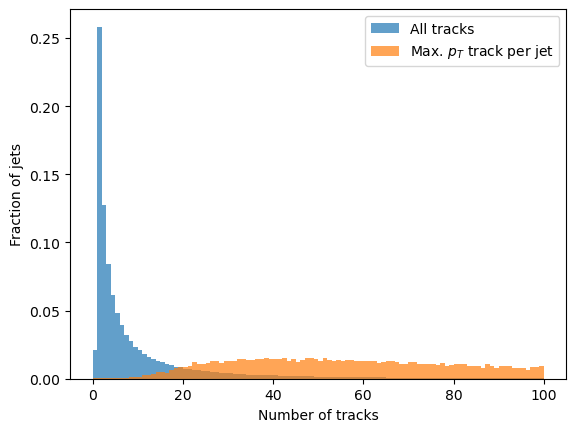

(array([    0,     0,     0, ..., 19999, 19999, 19999], shape=(537691,)), array([ 0,  1,  2, ..., 42, 43, 44], shape=(537691,)))


In [25]:
plt.figure()
plt.hist(a[a>0],bins=np.linspace(0,100,101),density=True,alpha=0.7, label='All tracks')
plt.hist(np.max(a,axis=-1),bins=np.linspace(0,100,101),density=True,alpha=0.7, label=r'Max. $p_{T}$ track per jet')

plt.xlabel(r'Number of tracks')
plt.ylabel('Fraction of jets')
plt.legend()
plt.show()
print(a.nonzero())